# Gradient boosting: correcting mistakes in sequence

Bagging and random forests build many trees **independently** — each on its
own resample, none aware the others exist — and average them at the end.
Boosting builds trees **in sequence**: each new tree looks at what the
trees so far got wrong, and is fit specifically to correct it. Independence
buys variance reduction. Sequential correction buys something bagging
cannot offer at all: the ability to keep reducing *bias* too, tree after
tree, for as long as there is a pattern left in the mistakes.

That power comes with a matching danger. Once there is no real pattern left
— once what remains is the noise this dataset deliberately injects — a
boosted ensemble keeps correcting anyway, because nothing tells it to stop.

By the end you will have:

1. implemented the residual-fitting idea from scratch on a regression toy,
   and watched a sum of small trees converge to a target function;
2. measured, on the loan data, exactly where more boosting rounds stop
   helping and start hurting;
3. built the lesson's final leaderboard: every method from this lesson,
   compared on the same folds against the same noise ceiling.

Handout: `Docs/trees_and_ensembles.md`, sections 7-9.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (GradientBoostingClassifier, RandomForestClassifier,
                               BaggingClassifier)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from loan_data import load_loans

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227"

np.random.seed(42)
X, y = load_loans()
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

## 1. Boosting from scratch: fitting the residuals

The clearest version of the idea is regression, where "what the trees so
far got wrong" has an exact meaning: the **residual**, $y - \hat{y}$. The
procedure:

> Start with a constant prediction, the target's mean. Fit a small tree to
> the current residuals. Add a small multiple of its prediction — the
> **learning rate** $\alpha$ — to the running total. Recompute residuals
> against the new total. Repeat.

$$F_0(x) = \bar{y}, \qquad F_t(x) = F_{t-1}(x) + \alpha \cdot h_t(x)$$

where $h_t$ is a tree fit to the residuals $y - F_{t-1}(x)$. Each tree only
has to explain what is *left over*, which is why boosted trees are kept
deliberately shallow — depth 2 or 3, "weak learners" — while bagging uses
trees grown as deep as they will go.

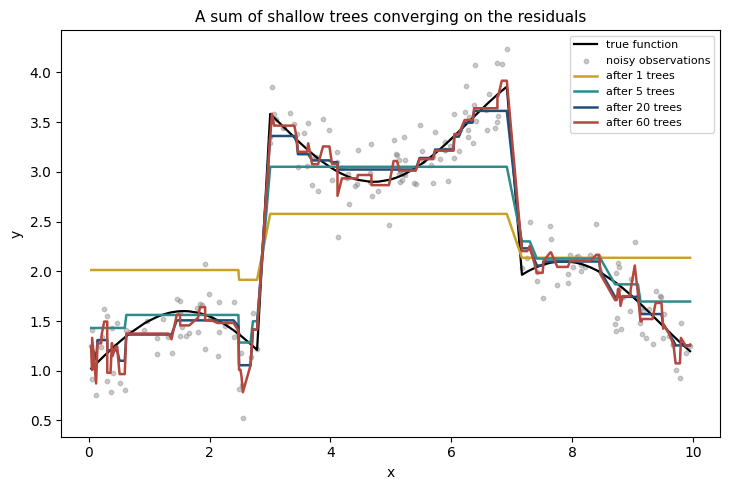

after  1 trees, mean squared error against the true function: 0.3947
after  5 trees, mean squared error against the true function: 0.0681
after 20 trees, mean squared error against the true function: 0.0119
after 60 trees, mean squared error against the true function: 0.0178


In [2]:
rng = np.random.default_rng(7)
x_toy = np.sort(rng.uniform(0, 10, 200))
true_function = np.where(x_toy < 3, 1.0, np.where(x_toy < 7, 3.5, 1.5)) \
    + 0.6 * np.sin(x_toy)
y_toy = true_function + rng.normal(0, 0.25, size=len(x_toy))
X_toy = x_toy.reshape(-1, 1)

eta = 0.3
prediction = np.full_like(y_toy, y_toy.mean())
snapshots = {}
trees = []
for t in range(1, 61):
    residual = y_toy - prediction
    tree = DecisionTreeRegressor(max_depth=2, random_state=0).fit(X_toy, residual)
    prediction = prediction + eta * tree.predict(X_toy)
    trees.append(tree)
    if t in (1, 5, 20, 60):
        snapshots[t] = prediction.copy()

fig, ax = plt.subplots(figsize=(7.4, 5.0))
ax.plot(x_toy, true_function, color="black", linewidth=1.6, label="true function")
ax.scatter(x_toy, y_toy, s=10, color="grey", alpha=.4, label="noisy observations")
for (t, pred), color in zip(snapshots.items(), [GOLD, TEAL, BLUE, RUST]):
    ax.plot(x_toy, pred, color=color, linewidth=1.8, label=f"after {t} trees")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("A sum of shallow trees converging on the residuals", fontsize=11)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "boosting_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

for t in (1, 5, 20, 60):
    mse = np.mean((snapshots[t] - true_function) ** 2)
    print(f"after {t:2d} trees, mean squared error against the true function: {mse:.4f}")

One tree barely dents the flat starting guess. Five sketch the coarse
shape — two of the three levels and a hint of the third. Twenty trace the
step function closely, oscillation included. By sixty, the ensemble is
tracking individual noisy points as well as the underlying shape — the same
overfitting story as notebook 1's unconstrained tree, arrived at by a
different route: not one tree grown too deep, but too many shallow trees
each chasing what little residual is left, most of it noise by that point.

## 2. The same idea, for classification

Classification boosts against the gradient of the **log-loss** rather than
a plain residual — the derivation is in the handout — but the mechanism a
learner needs to hold onto is identical: fit a shallow tree to what the
current ensemble gets wrong, shrink its contribution by $\alpha$, add it in,
repeat. scikit-learn's `GradientBoostingClassifier` implements exactly
this.

In [3]:
default_gbm = GradientBoostingClassifier(random_state=0)
cv = cross_val_score(default_gbm, X, y, cv=folds)
print(f"default GradientBoostingClassifier (100 trees, learning_rate=0.1): "
      f"{cv.mean():.3f} +/- {cv.std():.3f}")

default GradientBoostingClassifier (100 trees, learning_rate=0.1): 0.902 +/- 0.020


## 3. More trees always helps... until it doesn't

In [4]:
n_values = [5, 10, 20, 30, 50, 80, 120, 200, 400, 800]
rows = []
for n in n_values:
    clf = GradientBoostingClassifier(n_estimators=n, learning_rate=0.3,
                                      max_depth=3, random_state=0)
    cv = cross_val_score(clf, X, y, cv=folds)
    train = clf.fit(X, y).score(X, y)
    rows.append({"n_estimators": n, "train": train,
                 "cv_mean": cv.mean(), "cv_std": cv.std()})

boosting_table = pd.DataFrame(rows)
boosting_table

,n_estimators,train,cv_mean,cv_std
0,5,0.840000,0.845833,0.024721
1,10,0.887500,0.870000,0.024066
2,20,0.930000,0.895000,0.027310
3,30,0.948333,0.897500,0.020173
4,50,0.956667,0.891667,0.016874
5,80,0.978333,0.893333,0.011961
6,120,0.994167,0.895000,0.019965
7,200,1.000000,0.895000,0.016541
8,400,1.000000,0.894167,0.015943
9,800,1.000000,0.890000,0.018559


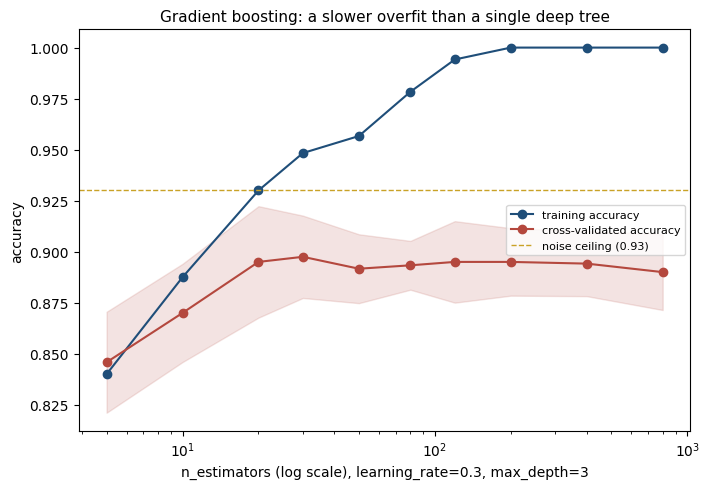

peak: n_estimators=30, cv=0.897
n_estimators=800: cv=0.890, train=1.000


In [5]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(boosting_table["n_estimators"], boosting_table["train"], "o-",
        color=BLUE, label="training accuracy")
ax.plot(boosting_table["n_estimators"], boosting_table["cv_mean"], "o-",
        color=RUST, label="cross-validated accuracy")
ax.fill_between(boosting_table["n_estimators"],
                 boosting_table["cv_mean"] - boosting_table["cv_std"],
                 boosting_table["cv_mean"] + boosting_table["cv_std"],
                 color=RUST, alpha=.15)
ax.axhline(0.93, color=GOLD, linestyle="--", linewidth=1, label="noise ceiling (0.93)")
ax.set_xscale("log")
ax.set_xlabel("n_estimators (log scale), learning_rate=0.3, max_depth=3")
ax.set_ylabel("accuracy")
ax.set_title("Gradient boosting: a slower overfit than a single deep tree", fontsize=11)
ax.legend(fontsize=8, loc="center right")
fig.tight_layout()
fig.savefig(FIGURES / "gbm_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

peak = boosting_table.loc[boosting_table["cv_mean"].idxmax()]
last = boosting_table.iloc[-1]
print(f"peak: n_estimators={int(peak['n_estimators'])}, cv={peak['cv_mean']:.3f}")
print(f"n_estimators={int(last['n_estimators'])}: cv={last['cv_mean']:.3f}, "
      f"train={last['train']:.3f}")

Training accuracy reaches 1.000 by around 200 trees and sits there —
exactly what notebook 1 showed a single unconstrained tree can do in one
step, arrived at gradually here, tree by tree. Cross-validated accuracy
behaves differently: it climbs quickly, peaks in the tens of trees, and
then drifts *down* by a few tenths of a point as hundreds more trees are
added, each one fitting a little more of the 7% label noise this dataset
was built to contain. The overfitting is real, but it is gentler than a
single tree's — a boosted ensemble at 800 trees is still close to its own
peak, where an unconstrained single tree lost several points of accuracy
outright. That gentleness is *why* early stopping matters for boosting
rather than making it optional: the damage from not stopping is smaller per
tree, easy to miss, and still there.

## 4. Learning rate: the same trade-off from the other side

In [6]:
lr_rows = []
for lr in (0.02, 0.05, 0.1, 0.3, 0.5, 1.0):
    clf = GradientBoostingClassifier(n_estimators=120, learning_rate=lr,
                                      max_depth=3, random_state=0)
    cv = cross_val_score(clf, X, y, cv=folds)
    train = clf.fit(X, y).score(X, y)
    lr_rows.append({"learning_rate": lr, "train": train,
                     "cv_mean": cv.mean(), "cv_std": cv.std()})

lr_table = pd.DataFrame(lr_rows)
lr_table

,learning_rate,train,cv_mean,cv_std
0,0.02,0.887500,0.871667,0.024636
1,0.05,0.914167,0.896667,0.022423
2,0.10,0.939167,0.901667,0.022142
3,0.30,0.994167,0.895000,0.019965
4,0.50,1.000000,0.892500,0.014289
5,1.00,1.000000,0.878333,0.019614


Fixing `n_estimators=120` and varying only $\alpha$ produces the same
elbow shape as varying tree count did, for the same reason: $\alpha$ and
`n_estimators` both control how much total correction the ensemble applies,
so the pair trades off against each other. A learning rate of 0.02 has not
finished fitting the signal by 120 trees — training accuracy is still
under 0.89 — while a learning rate of 1.0 has memorised the training set
completely and given back several points of cross-validated accuracy for
it. The best entry in this table sits in between, at a moderate learning
rate with room left for more trees rather than none.

## 5. The full leaderboard

In [7]:
models = {
    "majority baseline": None,
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2_000)),
    "single tree (depth 8)": DecisionTreeClassifier(max_depth=8, random_state=0),
    "single tree (unconstrained)": DecisionTreeClassifier(random_state=0),
    "bagging (100 trees)": BaggingClassifier(DecisionTreeClassifier(random_state=0),
                                              n_estimators=100, random_state=0),
    "random forest (100 trees)": RandomForestClassifier(n_estimators=100, random_state=0),
    "gradient boosting (30 trees, learning_rate=0.3)": GradientBoostingClassifier(
        n_estimators=30, learning_rate=0.3, max_depth=3, random_state=0),
}

leaderboard_rows = []
baseline_acc = max(y.mean(), 1 - y.mean())
for name, model in models.items():
    if model is None:
        leaderboard_rows.append({"model": name, "cv_mean": baseline_acc, "cv_std": 0.0})
        continue
    cv = cross_val_score(model, X, y, cv=folds)
    leaderboard_rows.append({"model": name, "cv_mean": cv.mean(), "cv_std": cv.std()})

leaderboard = pd.DataFrame(leaderboard_rows).sort_values("cv_mean", ascending=False)
leaderboard["of the 0.93 ceiling"] = leaderboard["cv_mean"] / 0.93
leaderboard

,model,cv_mean,cv_std,of the 0.93 ceiling
5,random forest (100 trees),0.910833,0.018371,0.979391
4,bagging (100 trees),0.904167,0.020242,0.972222
6,"gradient boosting (30 trees, learning_rate=0.3)",0.897500,0.020173,0.965054
2,single tree (depth 8),0.882500,0.009647,0.948925
3,single tree (unconstrained),0.851667,0.020683,0.915771
1,logistic regression,0.748333,0.030345,0.804659
0,majority baseline,0.613333,0.000000,0.659498


Every ensemble method — bagging, the random forest, gradient boosting —
lands within about two points of each other and closer to the 0.93 noise
ceiling than either single tree, tuned or not. The single tuned tree
(depth 8) is not far behind them and is the only model on this list a
person could read in full; the unconstrained tree is the worst model here
despite being, in a narrow sense, the most "powerful" one — proof, restated
one more time, that flexibility without a stopping rule is not an
advantage.

**No method here reaches the ceiling**, and none should: 7% of the labels
are wrong by construction, and a model that classified all of them
"correctly" against the flipped label would be modelling the noise, not the
rule.

## Summary

- Boosting fits shallow trees **in sequence**, each correcting the previous
  ensemble's residual (regression) or gradient of the loss (classification),
  scaled by a learning rate $\alpha$ before being added in.
- The from-scratch toy converged visibly: 1 tree barely moved the initial
  guess, 20 traced the true step function closely, 60 began tracking
  individual noise points.
- On the loan data, cross-validated accuracy peaked in the tens of trees and
  drifted down by a few tenths of a point over hundreds more, even as
  training accuracy saturated at 1.000 — a real but gentler overfit than a
  single unconstrained tree's.
- Learning rate and tree count trade off against each other: too small an
  $\alpha$ underfits a fixed budget of trees, too large overfits fast.
- The final leaderboard: every ensemble method landed within about two
  points of each other, all closer to the 0.93 noise ceiling than any
  single tree — and the single depth-tuned tree, the only model on the list
  a person could read end to end, was not far behind them.